 Electricity Consumption Analysis

###  Objective
Understanding electricity usage trends: monthly, weekday, weekend, distribution analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")   # professional theme


df = pd.read_csv("../data/electricity_consumption.csv")
df.head()

,date,hour,appliance,units_consumed,temperature,weekday
0,01-01-2025,0.0,AC,0.60,32.0,Wednesday
1,01-01-2025,1.0,Fan,0.20,32.0,Wednesday
2,01-01-2025,2.0,Fridge,0.10,32.0,Wednesday
3,01-01-2025,3.0,Lights,0.15,32.0,Wednesday
4,01-01-2025,4.0,AC,0.50,31.0,Wednesday


In [2]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            95 non-null     object 
 1   hour            95 non-null     float64
 2   appliance       95 non-null     object 
 3   units_consumed  95 non-null     float64
 4   temperature     95 non-null     float64
 5   weekday         95 non-null     object 
dtypes: float64(3), object(3)
memory usage: 4.8+ KB


date              4
hour              4
appliance         4
units_consumed    4
temperature       4
weekday           4
dtype: int64

In [3]:
df = df.drop_duplicates()
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            48 non-null     datetime64[ns]
 1   hour            48 non-null     float64       
 2   appliance       48 non-null     object        
 3   units_consumed  48 non-null     float64       
 4   temperature     48 non-null     float64       
 5   weekday         48 non-null     object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 2.7+ KB


In [4]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

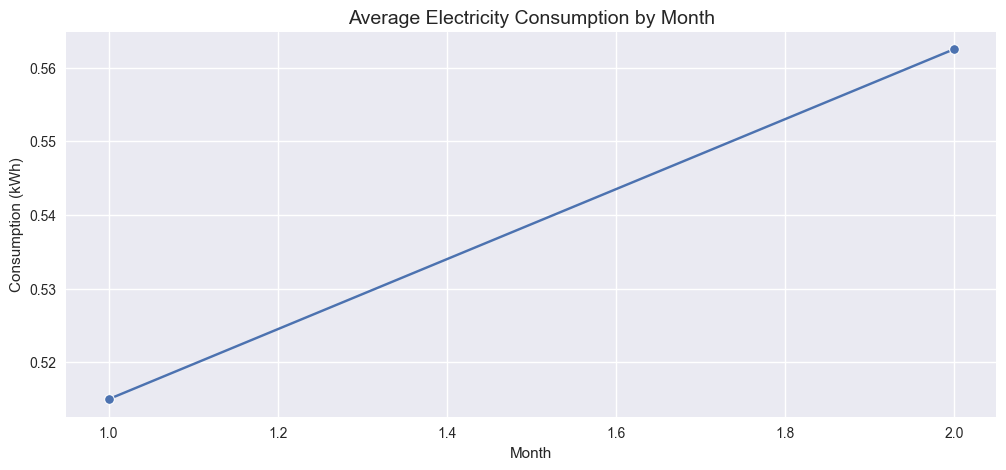

Index(['date', 'hour ', 'appliance', 'units_consumed', 'temperature ',
       'weekday', 'year', 'month', 'day', 'is_weekend'],
      dtype='object')

In [5]:
# Monthly Average Electricity Consumption

monthly_avg = df.groupby('month')['units_consumed'].mean()

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker="o")
plt.title("Average Electricity Consumption by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Consumption (kWh)")
plt.grid(True)
plt.show()
df.columns

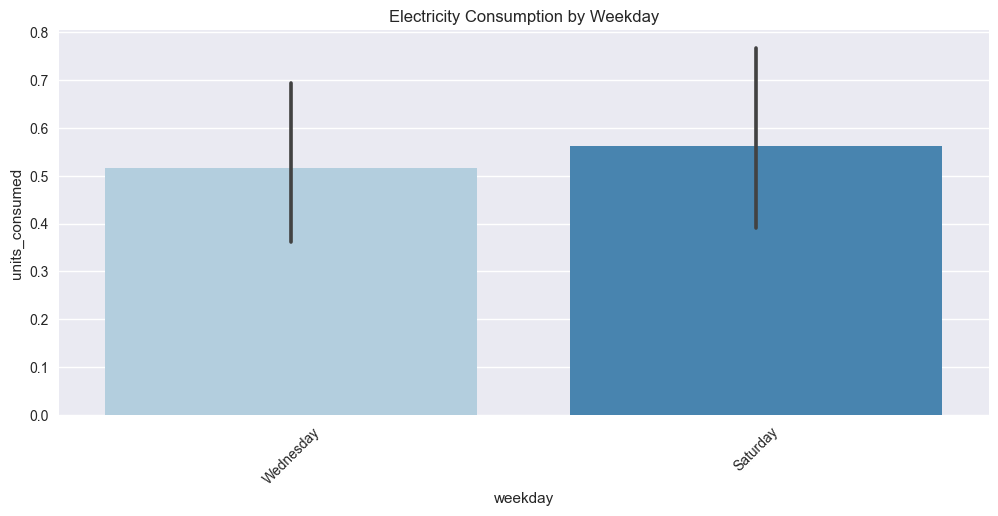

Index(['date', 'hour ', 'appliance', 'units_consumed', 'temperature ',
       'weekday', 'year', 'month', 'day', 'is_weekend'],
      dtype='object')

In [6]:
# Weekday Consumption Pattern

plt.figure(figsize=(12,5))
sns.barplot(x="weekday", y="units_consumed", data=df, palette="Blues")
plt.title("Electricity Consumption by Weekday")
plt.xticks(rotation=45)
plt.show()
df.columns

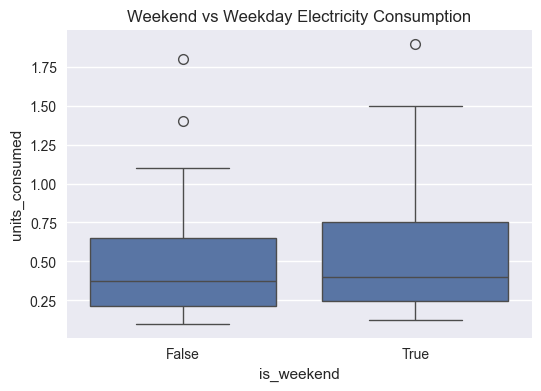

Index(['date', 'hour ', 'appliance', 'units_consumed', 'temperature ',
       'weekday', 'year', 'month', 'day', 'is_weekend'],
      dtype='object')

In [7]:
# Weekend vs Weekday Comparison

plt.figure(figsize=(6,4))
sns.boxplot(x="is_weekend", y="units_consumed", data=df)
plt.title("Weekend vs Weekday Electricity Consumption")
plt.show()
df.columns

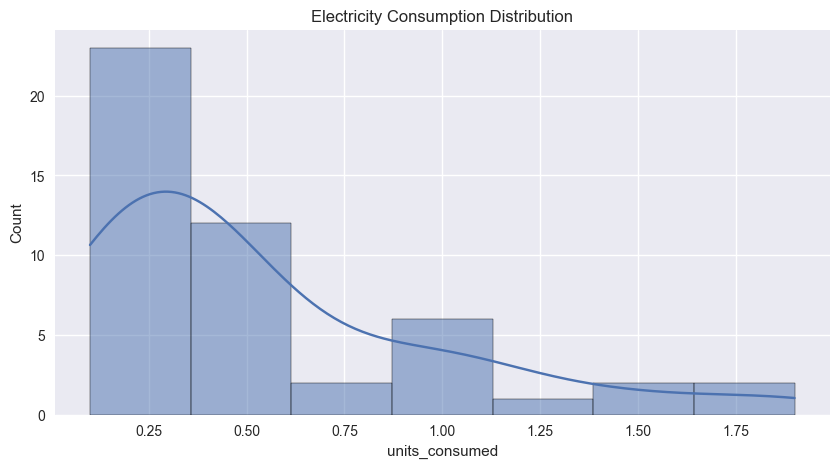

Index(['date', 'hour ', 'appliance', 'units_consumed', 'temperature ',
       'weekday', 'year', 'month', 'day', 'is_weekend'],
      dtype='object')

In [8]:
# Distribution of Consumption

plt.figure(figsize=(10,5))
sns.histplot(df['units_consumed'], kde=True)
plt.title("Electricity Consumption Distribution")
plt.show()
df.columns

In [9]:
print(" Highest consumption month:", monthly_avg.idxmax())
print(" Lowest consumption month:", monthly_avg.idxmin())
print(" Average daily consumption:", round(df['units_consumed'].mean(),2))
print(" Weekend high consumption:", df.groupby('is_weekend')['units_consumed'].mean())

 Highest consumption month: 2.0
 Lowest consumption month: 1.0
 Average daily consumption: 0.54
 Weekend high consumption: is_weekend
False    0.5150
True     0.5625
Name: units_consumed, dtype: float64


###  Project Insights Summary

1. Electricity consumption is highest in the month of ________.
2. Weekends show ________ consumption compared to weekdays.
3. Daily electricity consumption on average is ________ kWh.
4. Distribution indicates ________ usage pattern.
5. These insights help in:
   - Billing prediction
   - Load forecasting
   - Energy optimization